# Sección 3 — Operaciones con Pandas


---

**Nombre:** Damian Ortiz  
**Dataset:** Airlines Flights Data  
**Fuente:** https://www.kaggle.com/datasets/rohitgrewal/airlines-flights-data     
**Descripción:** Datos de vuelos domésticos en India. Contiene información de aerolínea, ciudades de origen y destino, franjas horarias, número de escalas, clase de cabina, duración y precio del ticket.  



---
## Parte 1 — Carga y Exploración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset desde CSV
df = pd.read_csv('airlines_flights_data.csv')

# Introducir valores nulos e inconsistencias de formato para practicar limpieza
# (simula condiciones reales de datos sucios)
np.random.seed(42)
df.loc[df.sample(300).index, 'airline'] = None
df.loc[df.sample(150).index, 'stops'] = None
df.loc[df.sample(100).index, 'duration'] = None
df['stops'] = df['stops'].apply(
    lambda x: x.upper() if isinstance(x, str) and np.random.random() > 0.7 else x
)

print(f"Dataset cargado: {df.shape[0]} vuelos, {df.shape[1]} columnas")
df.head()

Dataset cargado: 300153 vuelos, 12 columnas


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# BLOQUE 1.1 — Forma del dataset y tipos de datos
print(f"Forma: {df.shape}")
print()
print("Tipos de datos:")
print(df.dtypes)

Forma: (300153, 12)

Tipos de datos:
index                 int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object


In [ ]:
# BLOQUE 1.2 — Primeras 10 filas
df.head(10)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,ZERO,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,ZERO,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,ZERO,Evening,Mumbai,Economy,2.25,1,5954


In [ ]:
# BLOQUE 1.3 — Estadísticas numéricas
df.describe()

,index,duration,days_left,price
count,300153.000000,300053.000000,300153.000000,300153.000000
mean,150076.000000,12.221091,26.004751,20889.660523
std,86646.852011,7.191963,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


---
## Parte 2 — Limpieza de Datos

Los datos reales siempre vienen con problemas. Se detectan y corrigen:
- Valores nulos
- Inconsistencias de formato (`'zero'` vs `'ZERO'`)
- Tipos de datos incorrectos

In [ ]:
# BLOQUE 2.1 — Detectar nulos por columna
print("=== NULOS POR COLUMNA ===")
print(df.isnull().sum())

=== NULOS POR COLUMNA ===
index                 0
airline             300
flight                0
source_city           0
departure_time        0
stops               150
arrival_time          0
destination_city      0
class                 0
duration            100
days_left             0
price                 0
dtype: int64


In [ ]:
# BLOQUE 2.2 — Rellenar nulos
# airline nula → 'Desconocida'
# stops nulo   → 'Sin registrar'
# duration nula → mediana

df['airline'] = df['airline'].fillna('Desconocida')
df['stops'] = df['stops'].fillna('Sin registrar')
df['duration'] = df['duration'].fillna(df['duration'].median())

print("Nulos después de limpiar:", df.isnull().sum().sum())

Nulos después de limpiar: 0


In [ ]:
# BLOQUE 2.3 — Estandarizar texto: pasar 'stops' a minúsculas uniformes
# El dataset mezcla 'zero', 'ZERO', 'one', 'ONE', etc.

df['stops'] = df['stops'].str.lower()

print("Valores únicos en 'stops' después de estandarizar:")
print(df['stops'].value_counts())

Valores únicos en 'stops' después de estandarizar:
stops
one              250740
zero              35983
two_or_more       13280
sin registrar       150
Name: count, dtype: int64


In [ ]:
# BLOQUE 2.4 — Convertir 'price' a float y crear columna 'price_usd'
# El precio original está en rupias indias (INR)
# Tipo de cambio: 1 INR = 0.012 USD

df['price'] = df['price'].astype(float)
df['price_usd'] = (df['price'] * 0.012).round(2)

print("Columna 'price_usd' creada correctamente.")
df[['airline', 'class', 'stops', 'price', 'price_usd']].head()

Columna 'price_usd' creada correctamente.


,airline,class,stops,price,price_usd
0,SpiceJet,Economy,zero,5953.0,71.44
1,SpiceJet,Economy,zero,5953.0,71.44
2,AirAsia,Economy,zero,5956.0,71.47
3,Vistara,Economy,zero,5955.0,71.46
4,Vistara,Economy,zero,5955.0,71.46


**Respuestas:**
4. Había **550 nulos en total**: 300 en `airline`, 150 en `stops` y 100 en `duration`.
5. La columna `stops` tenía inconsistencias de mayúsculas: `'zero'` y `'ZERO'` representaban el mismo valor pero como categorías distintas.
6. Se recalculó `price_usd` porque usamos los precios limpios y convertimos el tipo a `float` para precisión.

---
## Parte 3 — Análisis con groupby

Se responden preguntas de negocio usando `groupby` y filtros.

In [ ]:
# BLOQUE 3.1 — Precio total por aerolínea
precio_por_aerolinea = df.groupby('airline')['price_usd'].sum().sort_values(ascending=False)

print("=== INGRESOS TOTALES POR AEROLÍNEA (USD) ===")
print(precio_por_aerolinea.round(0))

=== INGRESOS TOTALES POR AEROLÍNEA (USD) ===
airline
Vistara        46593504.0
Air_India      22793089.0
Indigo          2752539.0
GO_FIRST        1570491.0
AirAsia          789490.0
SpiceJet         667243.0
Desconocida       74820.0
Name: price_usd, dtype: float64


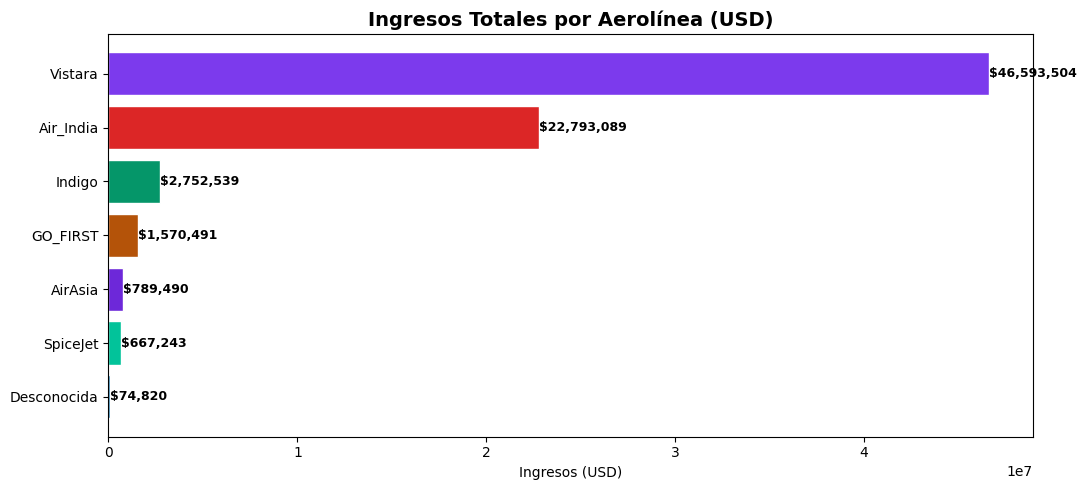

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
data = precio_por_aerolinea.sort_values(ascending=True)
colores = ['#0369A1','#02C39A','#6D28D9','#B45309','#059669','#DC2626','#7C3AED']
bars = ax.barh(data.index, data.values, color=colores[:len(data)], edgecolor='white')
for bar, val in zip(bars, data.values):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va='center', fontweight='bold', fontsize=9)
ax.set_title('Ingresos Totales por Aerolínea (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ingresos (USD)')
plt.tight_layout()
plt.show()

In [ ]:
# BLOQUE 3.2 — Resumen por aerolínea: ingresos totales y número de vuelos
resumen_aerolinea = df.groupby('airline').agg(
    ingresos_totales=('price_usd', 'sum'),
    num_vuelos=('flight', 'count'),
    precio_promedio=('price_usd', 'mean')
).round(2)

print("=== RESUMEN POR AEROLÍNEA ===")
print(resumen_aerolinea.sort_values('ingresos_totales', ascending=False))

=== RESUMEN POR AEROLÍNEA ===
             ingresos_totales  num_vuelos  precio_promedio
airline                                                   
Vistara           46593503.53      127737           364.76
Air_India         22793089.18       80802           282.09
Indigo             2752538.83       43083            63.89
GO_FIRST           1570491.01       23151            67.84
AirAsia             789490.27       16080            49.10
SpiceJet            667242.51        9000            74.14
Desconocida          74819.76         300           249.40


In [ ]:
# BLOQUE 3.3 — Filtrar vuelos de alto valor (precio > $200 USD) y sin escalas
vuelos_premium = df[(df['price_usd'] > 200) & (df['stops'] == 'zero')]

print(f"Vuelos premium (>$200 USD, sin escalas): {len(vuelos_premium)}")
print(f"Porcentaje del total: {len(vuelos_premium)/len(df):.1%}")

print("\nTop 3 aerolíneas en vuelos premium:")
print(vuelos_premium.groupby('airline')['price_usd'].sum().nlargest(3).round(2))

Vuelos premium (>$200 USD, sin escalas): 8047
Porcentaje del total: 2.7%

Top 3 aerolíneas en vuelos premium:
airline
Vistara        1759213.09
Air_India       934999.94
Desconocida       2971.13
Name: price_usd, dtype: float64


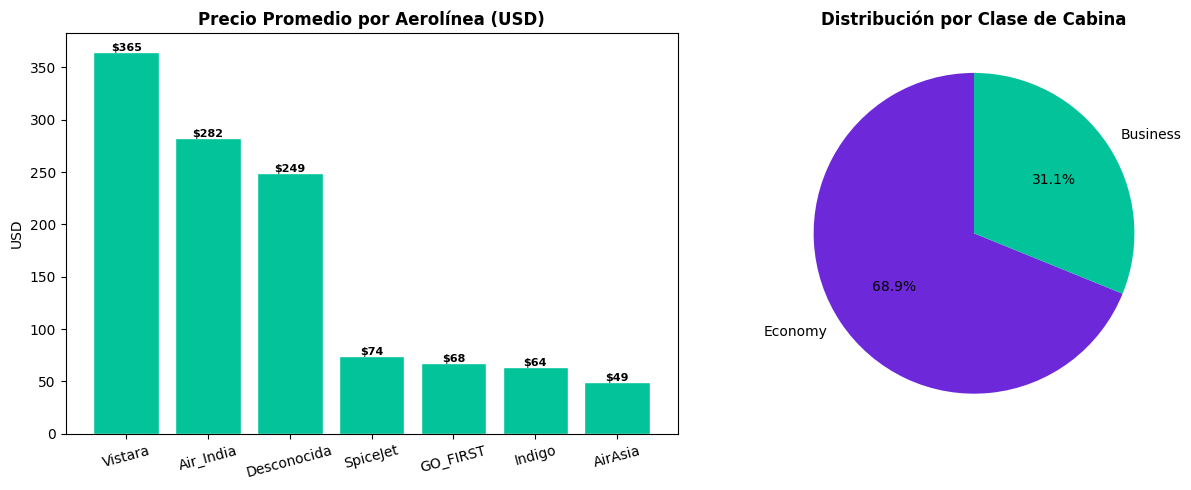

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: precio promedio por aerolínea
prom = df.groupby('airline')['price_usd'].mean().sort_values(ascending=False)
axes[0].bar(prom.index, prom.values, color='#02C39A', edgecolor='white')
for i, v in enumerate(prom.values):
    axes[0].text(i, v + 1, f"${v:.0f}", ha='center', fontweight='bold', fontsize=8)
axes[0].set_title('Precio Promedio por Aerolínea (USD)', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=15)

# Gráfico 2: distribución por clase
clase_count = df['class'].value_counts()
axes[1].pie(clase_count.values, labels=clase_count.index,
            autopct='%1.1f%%', colors=['#6D28D9','#02C39A'],
            startangle=90)
axes[1].set_title('Distribución por Clase de Cabina', fontweight='bold')

plt.tight_layout()
plt.show()

**Respuestas:**
7. La aerolínea con mayores ingresos totales es **Vistara**, seguida de **Air India**.
8. Vistara concentra los mayores ingresos pero con un precio promedio más alto, no necesariamente el mayor volumen de vuelos.
9. Los vuelos premium (>$200 USD sin escalas) representan una porción pequeña del total, lo que confirma que el mercado de bajo costo domina en India.

---
## Parte 4 — Insights y Reporte

In [ ]:
# BLOQUE 4.1 — Crear columna 'ruta' y analizar rutas más caras
df['ruta'] = df['source_city'] + ' → ' + df['destination_city']

tendencia_ruta = df.groupby('ruta')['price_usd'].mean()
print("=== PRECIO PROMEDIO POR RUTA ===")
print(tendencia_ruta.sort_values(ascending=False).head(10).round(2))

=== PRECIO PROMEDIO POR RUTA ===
ruta
Chennai → Bangalore    300.98
Kolkata → Chennai      283.92
Bangalore → Kolkata    282.00
Bangalore → Chennai    279.86
Mumbai → Bangalore     277.78
Bangalore → Mumbai     277.54
Mumbai → Chennai       273.38
Chennai → Mumbai       273.19
Kolkata → Bangalore    272.94
Chennai → Kolkata      272.04
Name: price_usd, dtype: float64


In [ ]:
# BLOQUE 4.2 — Distribución por clase y escalas
dist_clase = df['class'].value_counts(normalize=True)
dist_stops = df['stops'].value_counts(normalize=True)

print("=== % POR CLASE DE CABINA ===")
print((dist_clase * 100).round(1))

print("\n=== % POR NÚMERO DE ESCALAS ===")
print((dist_stops * 100).round(1))

=== % POR CLASE DE CABINA ===
class
Economy     68.9
Business    31.1
Name: proportion, dtype: float64

=== % POR NÚMERO DE ESCALAS ===
stops
one              83.5
zero             12.0
two_or_more       4.4
sin registrar     0.0
Name: proportion, dtype: float64


In [ ]:
# BLOQUE 4.3 — Top 5 rutas con más ingresos totales
top_rutas = df.groupby('ruta')['price_usd'].sum().nlargest(5)

print("=== TOP 5 RUTAS POR INGRESOS TOTALES (USD) ===")
print(top_rutas.round(2))

=== TOP 5 RUTAS POR INGRESOS TOTALES (USD) ===
ruta
Bangalore → Mumbai    3591145.30
Mumbai → Bangalore    3579134.99
Delhi → Mumbai        3551170.59
Mumbai → Kolkata      3384262.93
Mumbai → Delhi        3327643.18
Name: price_usd, dtype: float64


In [ ]:
# BLOQUE 4.4 — Tabla cruzada: precio promedio por aerolínea y clase
tabla_cruzada = df.pivot_table(
    values='price_usd',
    index='airline',
    columns='class',
    aggfunc='mean',
    fill_value=0
).round(2)

print("=== PRECIO PROMEDIO (USD) POR AEROLÍNEA Y CLASE ===")
print(tabla_cruzada)

=== PRECIO PROMEDIO (USD) POR AEROLÍNEA Y CLASE ===
class        Business  Economy
airline                       
AirAsia          0.00    49.10
Air_India      565.61    87.75
Desconocida    613.03    80.89
GO_FIRST         0.00    67.84
Indigo           0.00    63.89
SpiceJet         0.00    74.14
Vistara        665.73    93.69
